In [4]:
import os

import itertools

#from Bio import SeqIO, AlignIO

import gzip
import csv

import subprocess, gzip, tempfile
import shutil

from concurrent.futures import ProcessPoolExecutor, as_completed
import warnings


import traceback

from tqdm.notebook import tqdm

In [5]:
#import tsinfer
import tskit
#import msprime
#import tsdate

#import numpy as np
import pandas as pd

import datetime as dt
import time

# import matplotlib.pyplot as plt
# %matplotlib inline 

# from sklearn.linear_model import LinearRegression
# from itertools import combinations
# import random 

In [94]:
import re
from pathlib import Path

In [7]:
# t = tskit.load("trees/sim_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15.trees")

In [8]:
# t

# list files

In [88]:
# # even sampling
# even_dir = "../control/ctrl/even/"
# # uneven sampling
#base_dir = '../control/ctrl/trees/'

In [ ]:
base_dir = '../control/ctrl/trees/'
res_dir = 'out/'

In [90]:
files = os.listdir('../control/ctrl/downsampled_locations/')
treefiles = [file[:-4] + '.trees' for file in files if not file.startswith('c')] #exlude control 
sim_locs = [file[:-4] + '.csv' for file in files if file.startswith('sim')]
inf_locs = [file[:-4] + '.csv' for file in files if file.startswith('inf')]

In [80]:
# function for extracting file prefix + params 

def get_params(file):
    f = file.split("_")
    type = f[0]
    pm = f[3][2:]
    mr = f[4][2:] 
    seed = f[5].split(".")[0][4:] 

    return [type, pm, mr, seed]


# def get_prefix(file):
#     prefix = file.split(".trees")[0] 

#     return prefix 
    

In [97]:
Path(files[0]).stem

'sim_ss_mu2.500e-8_pm5.000e-3_mr5.000e-3_seed24'

# metadata

In [ ]:
def get_metadata(trees_file):
    ts = tskit.load(base_dir+trees_file)

    data = {
    'sample_id': t.samples(),
    'location': [t.node(u).population for u in t.samples()]
    }

    data = pd.DataFrame(data)

    metadata_file = outfile = Path(trees_file).stem + ".tsv"

    data.to_csv(metadata_file, index = False, sep = '\t')
    

In [89]:
base_dir+files[0]

'../control/ctrl/trees/sim_ss_mu2.500e-8_pm5.000e-3_mr5.000e-3_seed24.trees'

In [96]:
Path(sim_locs[0]).stem

'sim_ss_mu2.500e-8_pm5.000e-3_mr5.000e-3_seed24'

# subtrees (sim)

In [ ]:
def get_subtrees_sim(trees_file): 
    #desc = "" # ? 
    dir = Path(trees_file).stem
    Path(f"subtrees/{dir}").mkdir(exist_ok=True)
    ts = tskit.load(base_dir+trees_file)

    # global node ids
    id_labels = {node.id: str(node.id) for node in t.nodes()}
    
    for tree in t.trees():
        filename = f"subtrees/{dir}/index{tree.index:04d}.nwk"
        with open(filename, "w") as f:
            f.write(tree.newick(node_labels=id_labels))

def get_subtrees_inf(trees_file): 
    #desc = "" #? 
    dir = Path(trees_file).stem
    Path(f"subtrees/{dir}").mkdir(exist_ok=True)
    
    ts = tskit.load(base_dir+trees_file)

    # global node ids
    id_labels = {node.id: str(node.id) for node in t.nodes()}
    
    for i in range(1,it.num_trees-1): #remove flanking trees
        tree = it.at_index(i)
        filename = f"subtrees/{dir}/index{tree.index:04d}.nwk"
        with open(filename, "w") as f:
            f.write(tree.newick(node_labels=id_labels))


# run multi_tree_dta

# validation

## translating output to scoring 

In [ ]:
def score_sim(loc_file, res_file): 
    loc = pd.read_csv(base_dir+loc_file)
    loc['mrca_population'] = loc['mrca_population'].str[-1:]
    res = pd.read_csv(res_dir+res_file, sep = "\t")
    res = res.rename(columns = {'TREE_INDEX':'index', 'NODE_NAME':'node'})
    merge = pd.merge(loc, res, on = ['node', 'index'], how='left')
    merge['score'] = np.where(merge['mrca_population'].astype(str) == merge['STATE'].astype(str), 1, 0)

    outfile = Path(loc_file).stem
    merge.to_csv(f'summary/{outfile}.csv', index = False)

    #return merge


def score_inf(loc_file_sim, loc_file_inf res_file): 
    locs = pd.read_csv(base_dir+loc_file_sim)
    locs['mrca_population'] = locs['mrca_population'].str[-1:]

    loci = pd.read_csv(base_dir+loc_file_inf)
    loci = loci.drop(columns=['mrca_population'])
    loci = loci.merge(locs[['sample_a', 'sample_b', 'bin', 'mrca_population', 'node_height_sim']], on=['sample_a', 'sample_b', 'bin'], how='left')
    
    res = pd.read_csv(res_dir+res_file, sep = "\t")
    res = res.rename(columns = {'TREE_INDEX':'index', 'NODE_NAME':'node'})

    merge = pd.merge(loci, res, on = ['index', 'node'], how='left')
    merge['score'] = np.where(merge['mrca_population'].astype(str) == merge['STATE'].astype(str), 1, 0)
    
    outfile = Path(loc_file).stem
    merge.to_csv(f'summary/{outfile}.csv', index = False)

    #return merge


def score_ctrl(loc_file_sim, loc_file_ctrl)
    res = pd.read_csv(base_dir+loc_file_ctrl)
    res['population'] = res['population'] - 1
    res = res.rename(columns = {'population':'STATE'})

    locs = pd.read_csv(base_dir+loc_file_sim)
    locs['mrca_population'] = locs['mrca_population'].str[-1:]

    merge = locs.merge(res[['sample_a', 'sample_b','STATE']], on = ['sample_a', 'sample_b'], how= 'left')
    merge['score'] = np.where(merge['mrca_population'].astype(str) == merge['STATE'].astype(str), 1, 0)

    outfile = Path(loc_file).stem
    merge.to_csv(f'summary/{outfile}.csv', index = False)

    #return merge
    

## run all

In [ ]:
# tree_files
# sim_locs
# inf_locs 

## export

In [ ]:
## export each run df to /out; 
# in a different notebook, merge dfs to perform glm (score ~ node_height_sim) & perform summary calculations

### summarize

In [ ]:
# def summarize_per_bin(merge_sim, merge_inf, merge_ctrl):
#     sim_summary = sim_merge.groupby('bin').agg(
#     mean_score=('score', 'mean'),
#     median_score=('score', 'median')
#     )

#     inf_summary = inf_merge.groupby('bin').agg(
#     mean_score=('score', 'mean'),
#     median_score=('score', 'median')
#     )

#     ctrl_summary = ctrl_merge.groupby('bin').agg(
#     mean_score=('score', 'mean'),
#     median_score=('score', 'median')
#     )

#     df = pd.DataFrame({
#     'bin': "", ##################################### or just index 
#     'simulated': sim_summary['mean_score'],
#     'control': ctrl_summary['mean_score'],
#     'inferred': inf_summary['mean_score'],  
    
#     })


# def summarize_per_run(merge_sim, merge_inf, merge_ctrl): 

#     df = pd.DataFrame({
#     'simulated': merge_sim['score'].agg(['mean']).values[0],
#     'control': merge_ctrl['score'].agg(['mean']).values[0],
#     'inferred': merge_inf['score'].agg(['mean']).values[0],  
#     })

#     return df

# ## some way to include this in a larger dataframe w/ labels ... input has to be a filename or filenametype, which is queries throughout directories for all sim/inf/ctrl files w/ that label 
# ## so first thing to do is query a particular dir for all the labels, then call every function from there --> snakefile wildcard 

In [ ]:
# def glm_node_height(merge_sim, merge_inf, merge_ctrl): 
#     df = pd.merge([merge_sim, merge_inf, merge_ctrl]) 
#     df.groupby(columns=['node_height_sim', 'score'])

### plot results

In [160]:
# import seaborn as sns

In [166]:
# df = pd.DataFrame({
#     'simulated': sim_summary['mean_score'],
#     'control': ctrl_summary['mean_score'],
#     'inferred': inf_summary['mean_score'],  
    
# })

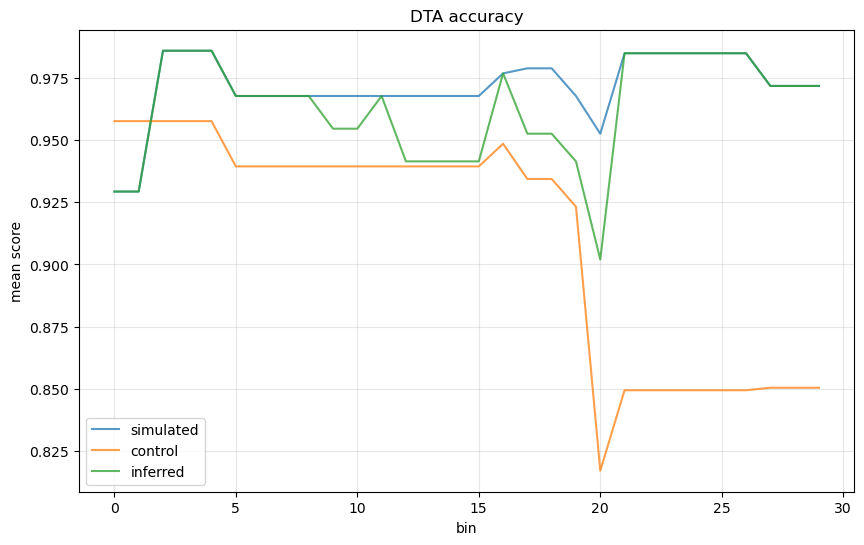

In [175]:
# plt.figure(figsize=(10, 6))

# sns.lineplot(data=df, dashes=False, alpha = 0.75)

# plt.title('DTA accuracy')
# plt.xlabel('bin')
# plt.ylabel('mean score')
# plt.grid(True, linestyle='-', alpha=0.3)
# plt.legend()
# plt.show()